# 🦠 Measles Disease Spread Forecasting
## R₀ Estimation · SIR Modelling · Agent-Based Modelling (ABM)
### 5-Year Prediction for 195 Countries

This notebook provides a full pipeline for:
1. **Data Exploration** – Understanding measles case trends across countries
2. **R₀ Estimation** – Calculating the basic reproduction number per country
3. **SIR Modelling** – Compartmental epidemic modelling for forecasting
4. **Agent-Based Modelling (ABM)** – Stochastic simulation of disease spread
5. **5-Year Forecasting** – Predicted case trajectories through 2029

## 📦 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit, minimize
from scipy.stats import pearsonr
import random
from collections import defaultdict

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#ccccff',
    'xtick.color': '#aaaacc',
    'ytick.color': '#aaaacc',
    'text.color': '#eeeeff',
    'grid.color': '#2a2a4a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

FORECAST_YEARS = 5
LAST_DATA_YEAR = 2023
FORECAST_END   = LAST_DATA_YEAR + FORECAST_YEARS  # 2028

# Measles epidemiological constants
MEASLES_SERIAL_INTERVAL = 11.5   # days
MEASLES_GAMMA = 1 / 8             # recovery rate (infectious period ~8 days)
MEASLES_SIGMA = 1 / 11.5          # incubation rate (SEIR)
BASELINE_R0_MEASLES = 15          # classic range 12–18 for unvaccinated population

print("✅ Libraries loaded successfully")
print(f"📅 Forecasting from {LAST_DATA_YEAR+1} to {FORECAST_END}")

✅ Libraries loaded successfully
📅 Forecasting from 2024 to 2028


## 📂 2. Load & Explore Data

In [2]:
# ─── Load dataset ───────────────────────────────────────────────────────────
df = pd.read_csv('data.csv')

print(f"Dataset shape: {df.shape}")
print(f"Countries: {df['country_name'].nunique()}")
print(f"Year range: {int(df['year'].min())} – {int(df['year'].max())}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head(3)

Dataset shape: (4612, 20)
Countries: 195
Year range: 2000 – 2024

Columns:
['country_name', 'country_code', 'region', 'income', 'year', 'measles_cases_reported', 'pop_density', 'che_pct_gdp', 'che_per_capita_usd', 'che', 'gghed', 'pvtd', 'ext', 'oops_che', 'gghed_gdp', 'gghed_gge', 'gghed_per_capita_usd', 'private_per_capita_usd', 'oop_per_capita_usd', 'external_per_capita_usd']


,country_name,country_code,region,income,year,measles_cases_reported,pop_density,che_pct_gdp,che_per_capita_usd,che,gghed,pvtd,ext,oops_che,gghed_gdp,gghed_gge,gghed_per_capita_usd,private_per_capita_usd,oop_per_capita_usd,external_per_capita_usd
0,Afghanistan,AFG,EMR,Low,2002,2486.0,32.776961,9.443391,16.706974,16880.626953,150.477919,14411.937500,2318.211561,85.375603,0.084181,1.212456,0.148930,14.263682,14.263682,2.294364
1,Afghanistan,AFG,EMR,Low,2003,798.0,34.854344,8.941258,17.746025,19671.931641,1432.204037,16931.472656,1308.254963,86.069191,0.650963,5.457679,1.291989,15.273861,15.273860,1.180175
2,Afghanistan,AFG,EMR,Low,2004,466.0,36.123230,9.808474,21.423004,24149.441406,1336.737221,20412.941406,2399.763206,84.527588,0.542926,3.602968,1.185821,18.108349,18.108349,2.128833


In [3]:
# ─── Basic cleaning ─────────────────────────────────────────────────────────
df['measles_cases_reported'] = pd.to_numeric(df['measles_cases_reported'], errors='coerce')
df['year'] = df['year'].astype(int)

# Fill missing cases with 0 (no report = assumed 0 or negligible)
df['cases'] = df['measles_cases_reported'].fillna(0).clip(lower=0)

# Approximate population from CHE (total health expenditure in millions USD / per capita)
# fallback: use pop_density as proxy weight
df['pop_approx'] = np.where(
    (df['che'] > 0) & (df['che_per_capita_usd'] > 0),
    (df['che'] / df['che_per_capita_usd']) * 1e6,
    df['pop_density'] * 1e5  # very rough fallback
)

# Vaccination proxy: inverse of OOP share — higher OOP → lower public coverage
df['vacc_proxy'] = 1 - (df['oops_che'].fillna(50) / 100)
df['vacc_proxy'] = df['vacc_proxy'].clip(0.1, 0.99)

print("✅ Cleaning done. Sample:")
df[['country_name','year','cases','pop_approx','vacc_proxy']].head(5)

✅ Cleaning done. Sample:


,country_name,year,cases,pop_approx,vacc_proxy
0,Afghanistan,2002,2486.0,1.010394e+09,0.146244
1,Afghanistan,2003,798.0,1.108526e+09,0.139308
2,Afghanistan,2004,466.0,1.127267e+09,0.154724
3,Afghanistan,2005,1296.0,1.207894e+09,0.210299
4,Afghanistan,2006,1990.0,1.269306e+09,0.231750


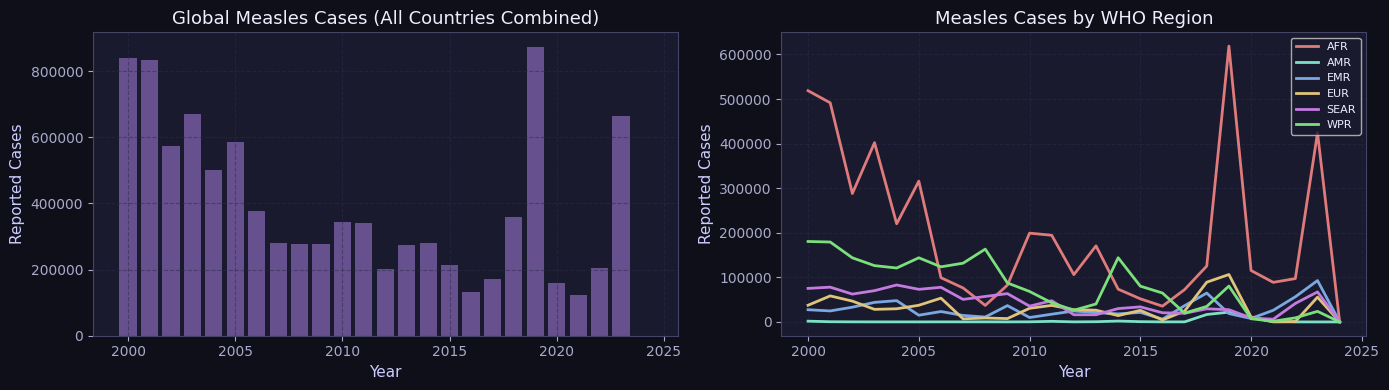

📊 Global trend plotted


In [4]:
# ─── Global trend ────────────────────────────────────────────────────────────
global_trend = df.groupby('year')['cases'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(global_trend.index, global_trend.values, color='#7b5ea7', alpha=0.8)
axes[0].set_title('Global Measles Cases (All Countries Combined)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Reported Cases')
axes[0].grid(True)

by_region = df.groupby(['year','region'])['cases'].sum().unstack(fill_value=0)
colors = ['#e07b7b','#7be0c4','#7ba8e0','#e0c47b','#c47be0','#7be07b']
for i, col in enumerate(by_region.columns):
    axes[1].plot(by_region.index, by_region[col], label=col,
                 color=colors[i % len(colors)], linewidth=2)
axes[1].set_title('Measles Cases by WHO Region')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Reported Cases')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('global_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Global trend plotted")

## 🔢 3. R₀ Estimation

**R₀** (basic reproduction number) is estimated per country using two approaches:

1. **Vaccination-derived R₀** using herd immunity threshold:  
   $R_0 = \dfrac{1}{1 - p_{\text{vac}}}$

2. **Exponential growth rate** fit to annual case data:  
   $R_0 = 1 + r \cdot T_g$  where $T_g$ is the generation time

The **effective reproduction number** Rₑ is then:  
$R_e = R_0 \times (1 - p_{\text{vac}})$

In [5]:
def estimate_r0_from_vaccination(vacc_coverage):
    """Herd immunity threshold: R0 = 1 / (1 - vc). Capped for stability."""
    vc = np.clip(vacc_coverage, 0.01, 0.98)
    return np.clip(1.0 / (1.0 - vc), 1.0, 30.0)

def estimate_r0_from_growth(cases_series, generation_time=11.5):
    """Fit exponential to case counts and derive R0 from growth rate."""
    cases = cases_series.dropna().values
    cases = cases[cases > 0]
    if len(cases) < 3:
        return np.nan
    t = np.arange(len(cases))
    log_cases = np.log(cases)
    # Linear regression on log scale
    slope, _ = np.polyfit(t, log_cases, 1)
    r_annual = slope  # per year
    r_daily = r_annual / 365
    r0 = 1 + r_daily * generation_time
    return np.clip(r0, 0.5, 30.0)

# ─── Compute per-country R₀ estimates ────────────────────────────────────────
country_stats = []
for country, grp in df.groupby('country_name'):
    grp = grp.sort_values('year')
    mean_vacc    = grp['vacc_proxy'].mean()
    latest_vacc  = grp['vacc_proxy'].iloc[-1]
    mean_cases   = grp['cases'].mean()
    latest_cases = grp['cases'].iloc[-1]
    latest_pop   = grp['pop_approx'].iloc[-1]
    region       = grp['region'].iloc[0]
    income       = grp['income'].iloc[0]

    r0_vacc   = estimate_r0_from_vaccination(latest_vacc)
    r0_growth = estimate_r0_from_growth(grp['cases'])

    # Blend: weight vacc estimate more heavily if growth estimate is noisy
    if np.isnan(r0_growth):
        r0_final = r0_vacc
    else:
        r0_final = 0.6 * r0_vacc + 0.4 * r0_growth

    r_eff = r0_final * (1 - latest_vacc)

    country_stats.append({
        'country': country,
        'region': region,
        'income': income,
        'mean_cases': mean_cases,
        'latest_cases': latest_cases,
        'pop': latest_pop,
        'vacc_coverage': latest_vacc,
        'r0_vacc': r0_vacc,
        'r0_growth': r0_growth,
        'r0': r0_final,
        'r_eff': r_eff,
    })

stats_df = pd.DataFrame(country_stats)
print(f"✅ R₀ estimated for {len(stats_df)} countries")
stats_df[['country','r0','r_eff','vacc_coverage']].sort_values('r0', ascending=False).head(10)

✅ R₀ estimated for 195 countries


,country,r0,r_eff,vacc_coverage
119,Nauru,30.000000,0.300000,0.990000
126,Niue,30.000000,0.300000,0.990000
89,Kiribati,30.000000,0.872572,0.970914
107,Marshall Islands,30.000000,0.315884,0.989471
178,Tuvalu,30.000000,0.300000,0.990000
159,Solomon Islands,30.000000,0.948148,0.968395
111,Micronesia (Federated States of),18.368861,0.474111,0.974189
39,Cook Islands,16.638462,0.614631,0.963060
144,Rwanda,15.032741,0.616342,0.959000
22,Botswana,14.487429,0.616971,0.957413


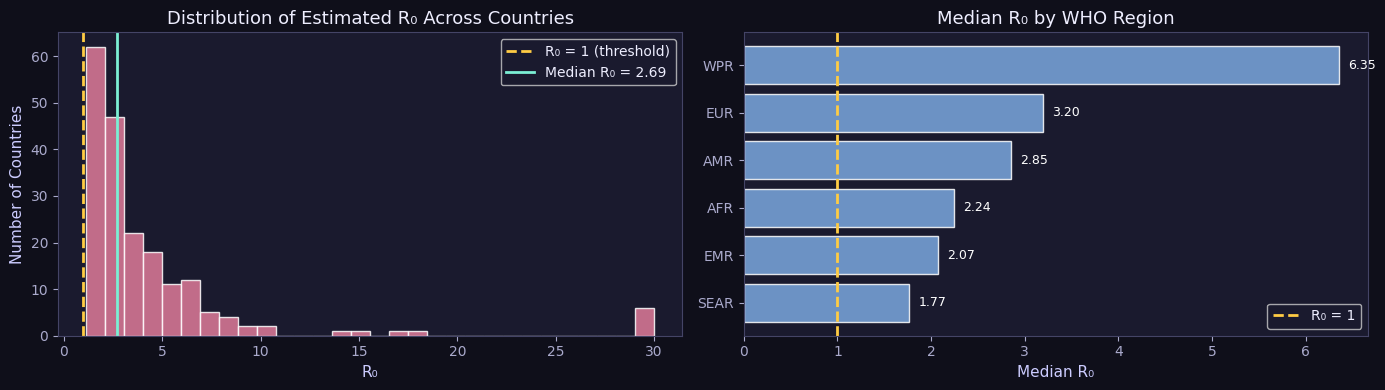

In [6]:
# ─── R₀ Distribution plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(stats_df['r0'].dropna(), bins=30, color='#e07b9a', edgecolor='#fff', alpha=0.85)
axes[0].axvline(1.0, color='#ffcc44', linestyle='--', lw=2, label='R₀ = 1 (threshold)')
axes[0].axvline(stats_df['r0'].median(), color='#7befd4', linestyle='-', lw=2,
                label=f'Median R₀ = {stats_df["r0"].median():.2f}')
axes[0].set_title('Distribution of Estimated R₀ Across Countries')
axes[0].set_xlabel('R₀')
axes[0].set_ylabel('Number of Countries')
axes[0].legend()

region_r0 = stats_df.groupby('region')['r0'].median().sort_values()
bars = axes[1].barh(region_r0.index, region_r0.values, color='#7ba8e0', alpha=0.85, edgecolor='#fff')
axes[1].axvline(1.0, color='#ffcc44', linestyle='--', lw=2, label='R₀ = 1')
for bar, val in zip(bars, region_r0.values):
    axes[1].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9, color='white')
axes[1].set_title('Median R₀ by WHO Region')
axes[1].set_xlabel('Median R₀')
axes[1].legend()

plt.tight_layout()
plt.savefig('r0_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 🧬 4. SIR / SEIR Modelling

We use an **SEIR** model (Susceptible → Exposed → Infectious → Recovered) that accounts for measles' ~11.5-day incubation period.

$$\frac{dS}{dt} = -\frac{\beta S I}{N}$$
$$\frac{dE}{dt} = \frac{\beta S I}{N} - \sigma E$$
$$\frac{dI}{dt} = \sigma E - \gamma I$$
$$\frac{dR}{dt} = \gamma I$$

Where:
- $\beta = R_0 \cdot \gamma$ (transmission rate)
- $\sigma = 1/11.5$ (incubation rate)
- $\gamma = 1/8$ (recovery rate)
- Initial **S** accounts for vaccination coverage

In [7]:
def seir_model(t, y, beta, sigma, gamma, N):
    """SEIR ODE system."""
    S, E, I, R = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I
    return [dSdt, dEdt, dIdt, dRdt]


def run_seir_forecast(N, r0, vacc_coverage, initial_cases, years=5,
                      gamma=1/8, sigma=1/11.5):
    """
    Run a SEIR forecast.
    Returns yearly case totals for `years` years.
    """
    beta = r0 * gamma
    I0 = max(initial_cases, 1)
    E0 = I0 * 2
    R0_pop = N * vacc_coverage          # already recovered / vaccinated
    S0 = max(N - R0_pop - I0 - E0, 1)

    t_span = (0, years * 365)
    t_eval = np.linspace(0, years * 365, years * 365 + 1)

    try:
        sol = solve_ivp(
            seir_model,
            t_span,
            [S0, E0, I0, R0_pop],
            args=(beta, sigma, gamma, N),
            method='RK45',
            t_eval=t_eval,
            max_step=1.0
        )
        # Integrate new infections per year
        new_inf = np.diff(N - sol.y[0] - sol.y[1])  # daily ΔS (outflow)
        new_inf = np.clip(new_inf, 0, None)
        yearly = []
        for y in range(years):
            start = y * 365
            end   = (y + 1) * 365
            yearly.append(new_inf[start:end].sum())
        return yearly, sol
    except Exception:
        return [initial_cases] * years, None


print("✅ SEIR model functions defined")

✅ SEIR model functions defined


In [8]:
# ─── Run SEIR for all countries ──────────────────────────────────────────────
forecast_years_list = list(range(LAST_DATA_YEAR + 1, FORECAST_END + 1))

seir_forecasts = []
for _, row in stats_df.iterrows():
    N   = max(row['pop'], 1e5)
    r0  = row['r0'] if not np.isnan(row['r0']) else BASELINE_R0_MEASLES
    vc  = row['vacc_coverage']
    ic  = max(row['latest_cases'], 1)

    yearly_cases, _ = run_seir_forecast(N, r0, vc, ic, years=FORECAST_YEARS)

    record = {'country': row['country'], 'region': row['region'],
              'income': row['income'], 'r0': r0, 'r_eff': row['r_eff']}
    for yr, cnt in zip(forecast_years_list, yearly_cases):
        record[yr] = cnt
    seir_forecasts.append(record)

seir_df = pd.DataFrame(seir_forecasts)
print(f"✅ SEIR forecasts complete for {len(seir_df)} countries")
seir_df[['country','r0'] + forecast_years_list].head(8)

✅ SEIR forecasts complete for 195 countries


,country,r0,2024,2025,2026,2027,2028
0,Afghanistan,1.177961,73499.529897,12728.476529,2212.855117,3.846980e+02,66.878305
1,Albania,1.642387,172.378056,2.848097,0.047486,7.916987e-04,0.000012
2,Algeria,1.730832,2520.125432,31.034972,0.385972,4.798889e-03,0.000047
3,Andorra,5.778756,7.416881,0.004569,0.000003,1.775334e-09,0.000000
4,Angola,2.243032,35321.390654,152.063559,0.663092,2.883911e-03,0.000002
5,Antigua and Barbuda,4.805945,56.027875,54.765374,52.587251,4.955969e+01,45.889795
6,Argentina,2.853927,8.926001,0.019096,0.000032,0.000000e+00,0.000000
7,Armenia,1.144340,15946.984197,3507.055766,773.991724,1.708131e+02,37.696786


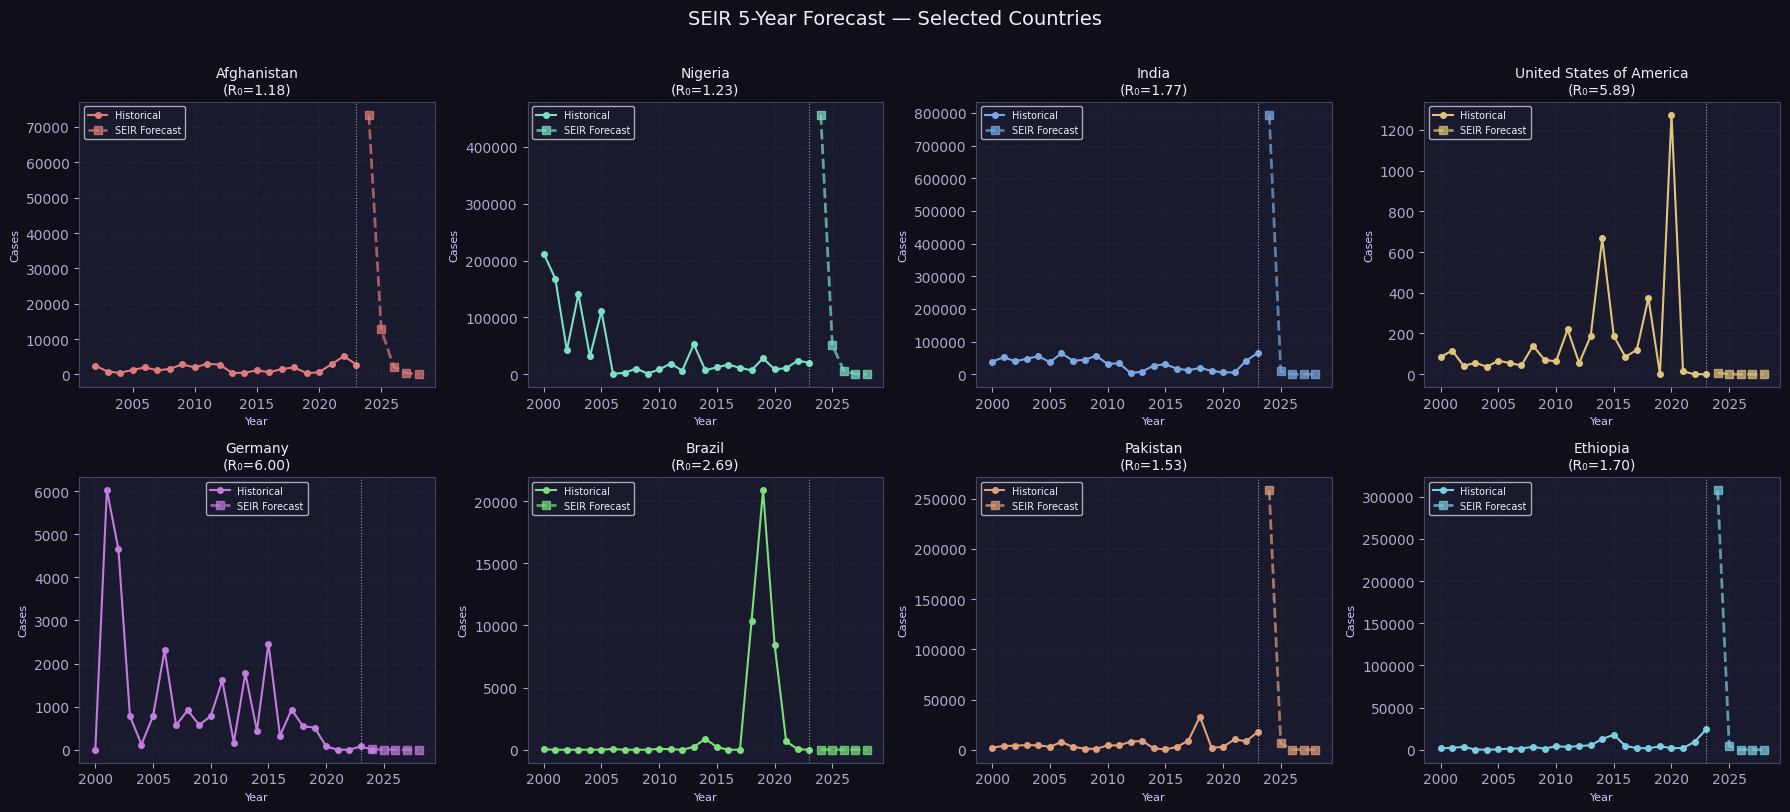

In [9]:
# ─── Plot SEIR for selected focus countries ───────────────────────────────────
focus_countries = [
    'Afghanistan', 'Nigeria', 'India', 'United States of America',
    'Germany', 'Brazil', 'Pakistan', 'Ethiopia'
]
focus_countries = [c for c in focus_countries if c in stats_df['country'].values]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

palette = ['#e07b7b','#7be0c4','#7ba8e0','#e0c47b',
           '#c47be0','#7be07b','#e0a07b','#7bcde0']

for idx, country in enumerate(focus_countries[:8]):
    ax = axes[idx]
    # historical
    hist = df[df['country_name'] == country].sort_values('year')
    ax.plot(hist['year'], hist['cases'], 'o-', color=palette[idx],
            lw=1.5, ms=4, label='Historical')

    # forecast
    frow = seir_df[seir_df['country'] == country]
    if not frow.empty:
        f_cases = [frow[yr].values[0] for yr in forecast_years_list]
        ax.plot(forecast_years_list, f_cases, 's--', color=palette[idx],
                lw=2, ms=6, alpha=0.7, label='SEIR Forecast')
        r0_val = frow['r0'].values[0]
        ax.set_title(f'{country}\n(R₀={r0_val:.2f})', fontsize=10)
    else:
        ax.set_title(country, fontsize=10)

    ax.axvline(LAST_DATA_YEAR, color='#ffffff', lw=0.8, linestyle=':', alpha=0.6)
    ax.set_xlabel('Year', fontsize=8)
    ax.set_ylabel('Cases', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True)

plt.suptitle('SEIR 5-Year Forecast — Selected Countries', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig('seir_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

## 🤖 5. Agent-Based Model (ABM)

The ABM simulates individual-level interactions in a scaled population:

- **Agents** are in states: **S**usceptible, **E**xposed, **I**nfectious, **R**ecovered
- Each infectious agent contacts a random subset of agents per day
- Contacts with susceptibles become exposed with probability `β_prob`
- After incubation (`sigma_days`) exposed → infectious
- After infectious period (`gamma_days`) infectious → recovered
- **Vaccination** is applied at initialization (fraction of agents start in R)

Due to computational limits, ABM runs on a **scaled population** (e.g. 5,000 agents representing the full country).

In [10]:
def run_abm(N_agents, r0, vacc_coverage, initial_infected=5,
            days=365, gamma_days=8, sigma_days=11,
            seed=42):
    """
    Simple stochastic ABM for SEIR disease spread.

    Parameters
    ----------
    N_agents        : int    — number of agents
    r0              : float  — basic reproduction number
    vacc_coverage   : float  — fraction of population vaccinated (→ start in R)
    initial_infected: int    — seed infections
    days            : int    — simulation duration in days
    gamma_days      : int    — mean infectious period
    sigma_days      : int    — mean incubation period
    seed            : int    — random seed

    Returns
    -------
    results : dict with daily S, E, I, R counts and cumulative cases
    """
    rng = np.random.default_rng(seed)

    # Daily contact rate such that expected transmissions = R0 over infectious period
    contacts_per_day = r0 / gamma_days
    p_transmit = 0.9  # probability of transmission per contact (effective)

    # Agent states: 0=S, 1=E, 2=I, 3=R
    state = np.zeros(N_agents, dtype=np.int8)  # all susceptible

    # Vaccinated agents → R
    n_vacc = int(vacc_coverage * N_agents)
    vacc_idx = rng.choice(N_agents, size=n_vacc, replace=False)
    state[vacc_idx] = 3

    # Seed infections
    susceptible_idx = np.where(state == 0)[0]
    if len(susceptible_idx) >= initial_infected:
        seed_idx = rng.choice(susceptible_idx, size=initial_infected, replace=False)
        state[seed_idx] = 2

    # Timers for E and I states
    timer = np.zeros(N_agents, dtype=np.int16)
    timer[state == 2] = rng.integers(1, gamma_days + 1, size=(state == 2).sum())

    # Track daily counts
    S_daily = np.zeros(days)
    E_daily = np.zeros(days)
    I_daily = np.zeros(days)
    R_daily = np.zeros(days)
    new_infections_daily = np.zeros(days)

    for day in range(days):
        # ── Transitions ──────────────────────────────────────────────────────
        # E → I when timer expires
        exposed_mask = (state == 1)
        timer[exposed_mask] -= 1
        newly_infectious = exposed_mask & (timer <= 0)
        state[newly_infectious] = 2
        timer[newly_infectious] = rng.integers(gamma_days - 2, gamma_days + 3,
                                               size=newly_infectious.sum())

        # I → R when timer expires
        infectious_mask = (state == 2)
        timer[infectious_mask] -= 1
        newly_recovered = infectious_mask & (timer <= 0)
        state[newly_recovered] = 3

        # ── Transmission ──────────────────────────────────────────────────────
        inf_agents = np.where(state == 2)[0]
        sus_agents = np.where(state == 0)[0]
        new_exp = 0

        if len(inf_agents) > 0 and len(sus_agents) > 0:
            n_contacts = max(1, int(contacts_per_day * len(inf_agents)))
            # Sample contacted susceptibles (with replacement)
            contacts = rng.choice(sus_agents, size=min(n_contacts, len(sus_agents)),
                                  replace=False)
            transmit = rng.random(len(contacts)) < p_transmit
            newly_exposed_idx = contacts[transmit]
            if len(newly_exposed_idx) > 0:
                state[newly_exposed_idx] = 1
                timer[newly_exposed_idx] = rng.integers(
                    sigma_days - 2, sigma_days + 4, size=len(newly_exposed_idx)
                )
                new_exp = len(newly_exposed_idx)

        # ── Record ────────────────────────────────────────────────────────────
        S_daily[day] = (state == 0).sum()
        E_daily[day] = (state == 1).sum()
        I_daily[day] = (state == 2).sum()
        R_daily[day] = (state == 3).sum()
        new_infections_daily[day] = new_exp

    return {
        'S': S_daily, 'E': E_daily, 'I': I_daily, 'R': R_daily,
        'new_infections': new_infections_daily,
        'total_infected': int(new_infections_daily.sum())
    }


print("✅ ABM function defined")

✅ ABM function defined


In [11]:
# ─── Run ABM for a few representative countries ───────────────────────────────
abm_countries = ['Afghanistan', 'Nigeria', 'Germany', 'United States of America']
abm_countries = [c for c in abm_countries if c in stats_df['country'].values]
N_AGENTS = 3000  # scaled down for speed

abm_results = {}
for country in abm_countries:
    row = stats_df[stats_df['country'] == country].iloc[0]
    r0  = row['r0'] if not np.isnan(row['r0']) else 12.0
    vc  = row['vacc_coverage']
    print(f"  Running ABM for {country} (R₀={r0:.2f}, vacc={vc:.0%})...", end=' ')
    result = run_abm(N_AGENTS, r0, vc, initial_infected=3, days=5*365)
    abm_results[country] = result
    print(f"Total infected (scaled): {result['total_infected']}")

print("\n✅ ABM runs complete")

  Running ABM for Afghanistan (R₀=1.18, vacc=23%)... Total infected (scaled): 1624
  Running ABM for Nigeria (R₀=1.23, vacc=28%)... Total infected (scaled): 1637
  Running ABM for Germany (R₀=6.00, vacc=89%)... Total infected (scaled): 319
  Running ABM for United States of America (R₀=5.89, vacc=89%)... Total infected (scaled): 325

✅ ABM runs complete


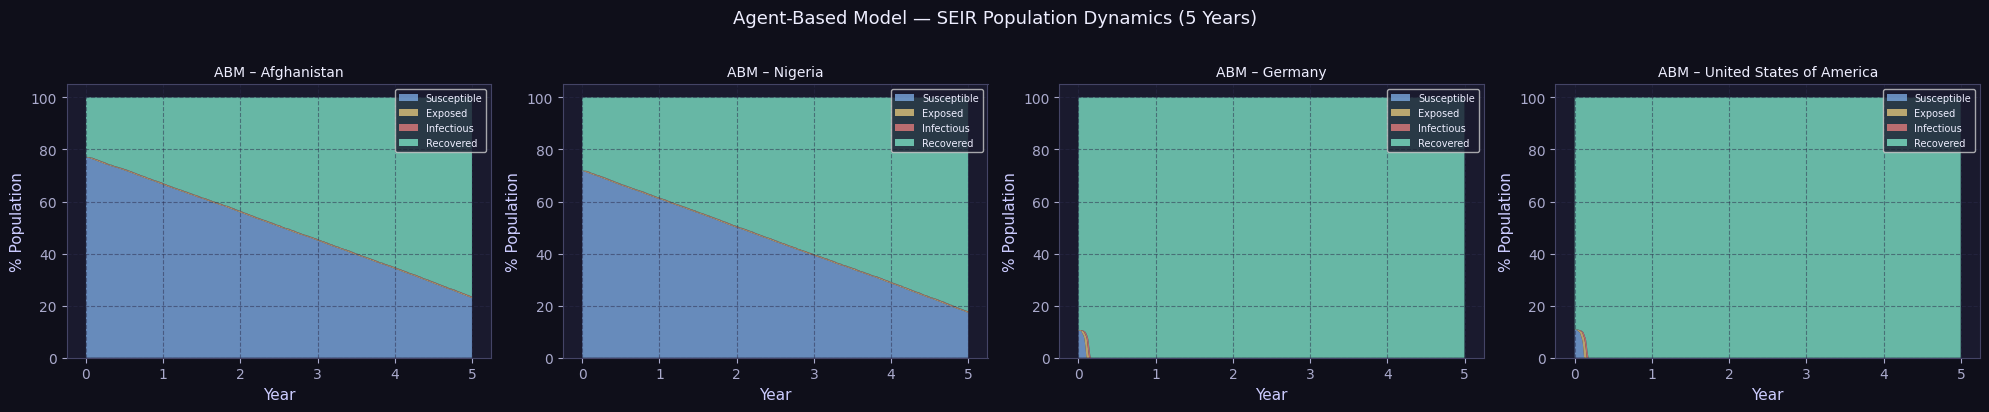

In [12]:
# ─── Plot ABM SEIR curves ─────────────────────────────────────────────────────
n_plots = len(abm_countries)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))
if n_plots == 1:
    axes = [axes]

for idx, country in enumerate(abm_countries):
    res = abm_results[country]
    ax  = axes[idx]
    t   = np.arange(len(res['S'])) / 365  # years

    ax.stackplot(t,
                 res['S'] / N_AGENTS * 100,
                 res['E'] / N_AGENTS * 100,
                 res['I'] / N_AGENTS * 100,
                 res['R'] / N_AGENTS * 100,
                 labels=['Susceptible', 'Exposed', 'Infectious', 'Recovered'],
                 colors=['#7ba8e0', '#e0c47b', '#e07b7b', '#7be0c4'],
                 alpha=0.8)
    ax.set_title(f'ABM – {country}', fontsize=10)
    ax.set_xlabel('Year')
    ax.set_ylabel('% Population')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True)

plt.suptitle('Agent-Based Model — SEIR Population Dynamics (5 Years)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('abm_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Running 8 Monte Carlo ABM runs for Afghanistan...
  Seed 0: 1665 total infected
  Seed 1: 1633 total infected
  Seed 2: 1626 total infected
  Seed 3: 1648 total infected
  Seed 4: 1615 total infected
  Seed 5: 1620 total infected
  Seed 6: 1655 total infected
  Seed 7: 1631 total infected


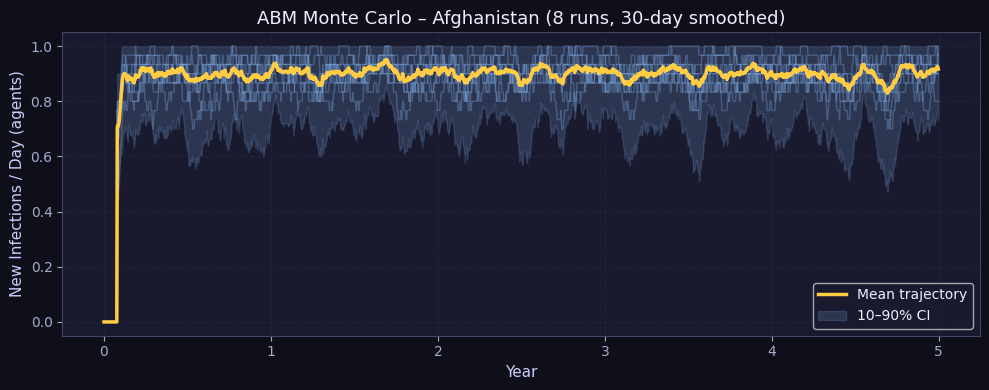

In [13]:
# ─── ABM Monte Carlo: Run multiple seeds for uncertainty bands ────────────────
MC_RUNS = 8
mc_country = abm_countries[0]  # Use first country as example
row = stats_df[stats_df['country'] == mc_country].iloc[0]
r0_mc = row['r0'] if not np.isnan(row['r0']) else 12.0
vc_mc = row['vacc_coverage']

print(f"Running {MC_RUNS} Monte Carlo ABM runs for {mc_country}...")
mc_new_inf = []
for s in range(MC_RUNS):
    res = run_abm(N_AGENTS, r0_mc, vc_mc, initial_infected=3, days=5*365, seed=s)
    mc_new_inf.append(res['new_infections'])
    print(f"  Seed {s}: {res['total_infected']} total infected")

mc_arr = np.array(mc_new_inf)
t_mc = np.arange(mc_arr.shape[1]) / 365

fig, ax = plt.subplots(figsize=(10, 4))
for run in mc_arr:
    # Smooth with 30-day rolling average
    smoothed = pd.Series(run).rolling(30).mean().fillna(0)
    ax.plot(t_mc, smoothed, alpha=0.35, color='#7ba8e0', lw=1)

mean_curve = pd.Series(mc_arr.mean(axis=0)).rolling(30).mean().fillna(0)
ax.plot(t_mc, mean_curve, color='#ffcc44', lw=2.5, label='Mean trajectory')

lo = pd.Series(np.percentile(mc_arr, 10, axis=0)).rolling(30).mean().fillna(0)
hi = pd.Series(np.percentile(mc_arr, 90, axis=0)).rolling(30).mean().fillna(0)
ax.fill_between(t_mc, lo, hi, alpha=0.2, color='#7ba8e0', label='10–90% CI')

ax.set_title(f'ABM Monte Carlo – {mc_country} ({MC_RUNS} runs, 30-day smoothed)')
ax.set_xlabel('Year')
ax.set_ylabel('New Infections / Day (agents)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('abm_montecarlo.png', dpi=150, bbox_inches='tight')
plt.show()

## 📈 6. Combined 5-Year Forecast Summary

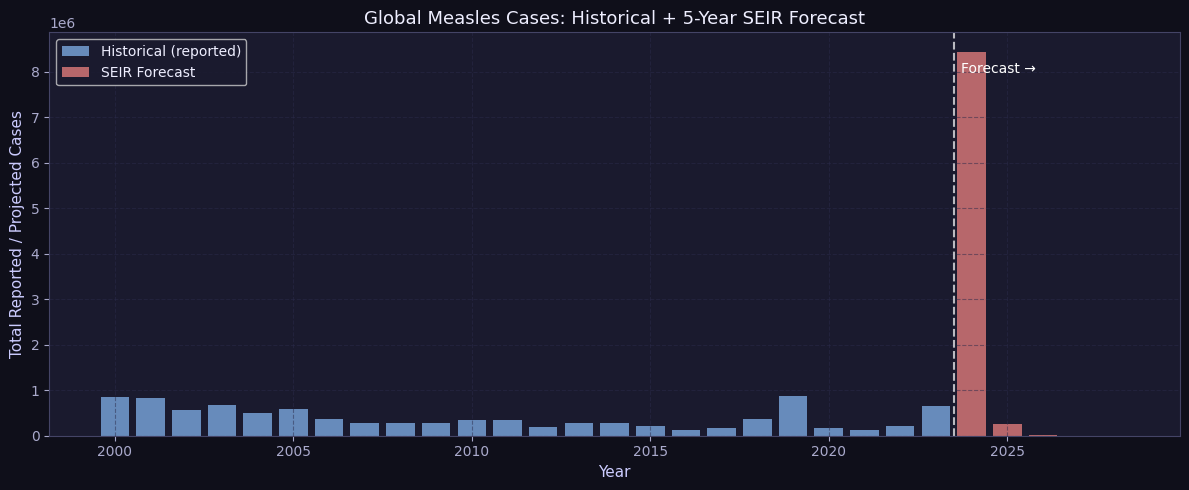


📊 Global SEIR forecast totals:
  2024: 8,448,827 projected cases
  2025: 259,019 projected cases
  2026: 22,668 projected cases
  2027: 3,846 projected cases
  2028: 1,798 projected cases


In [14]:
# ─── Aggregate global SEIR forecast ──────────────────────────────────────────
global_forecast = seir_df[forecast_years_list].sum()

# Historical global totals
hist_global = df.groupby('year')['cases'].sum()

fig, ax = plt.subplots(figsize=(12, 5))

# Historical bars
ax.bar(hist_global.index, hist_global.values, color='#7ba8e0', alpha=0.8,
       label='Historical (reported)')

# Forecast bars
ax.bar(forecast_years_list, global_forecast.values, color='#e07b7b', alpha=0.8,
       label='SEIR Forecast')

ax.axvline(LAST_DATA_YEAR + 0.5, color='white', lw=1.5, linestyle='--', alpha=0.7)
ax.text(LAST_DATA_YEAR + 0.7, ax.get_ylim()[1] * 0.9, 'Forecast →', color='white', fontsize=10)

ax.set_title('Global Measles Cases: Historical + 5-Year SEIR Forecast', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Total Reported / Projected Cases')
ax.legend(fontsize=10)
ax.grid(True)
plt.tight_layout()
plt.savefig('global_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Global SEIR forecast totals:")
for yr in forecast_years_list:
    print(f"  {yr}: {global_forecast[yr]:,.0f} projected cases")

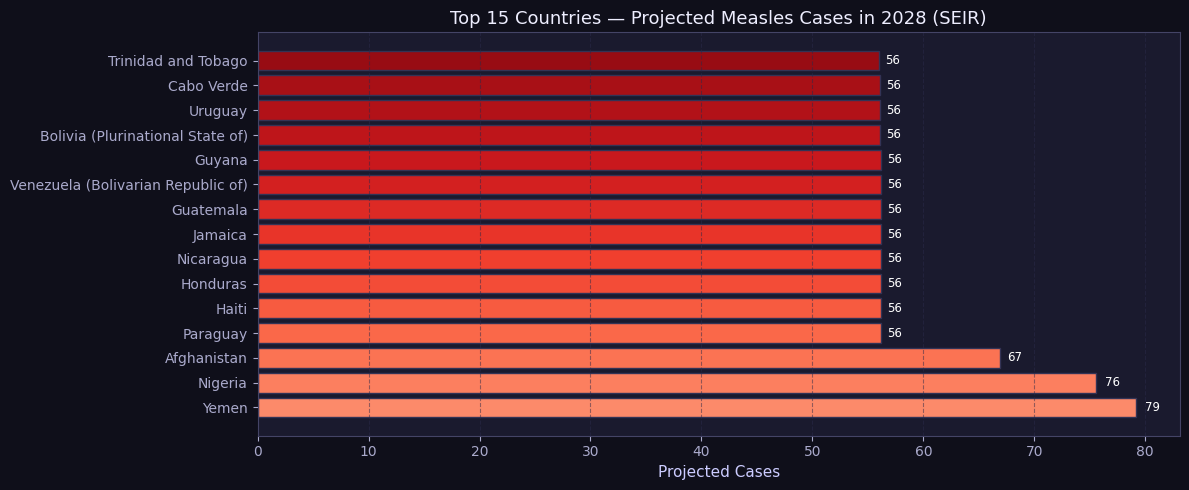

In [15]:
# ─── Top 15 highest-risk countries in 2028 ───────────────────────────────────
last_forecast_year = forecast_years_list[-1]
top15 = seir_df.nlargest(15, last_forecast_year)[['country','region','r0', 'r_eff'] + forecast_years_list]

fig, ax = plt.subplots(figsize=(12, 5))
colors_bar = plt.cm.Reds(np.linspace(0.4, 0.9, 15))
bars = ax.barh(top15['country'], top15[last_forecast_year],
               color=colors_bar, edgecolor='#333355')
for bar, val in zip(bars, top15[last_forecast_year]):
    ax.text(val * 1.01, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=8.5, color='white')
ax.set_title(f'Top 15 Countries — Projected Measles Cases in {last_forecast_year} (SEIR)', fontsize=13)
ax.set_xlabel('Projected Cases')
ax.grid(True, axis='x')
plt.tight_layout()
plt.savefig('top15_2028.png', dpi=150, bbox_inches='tight')
plt.show()

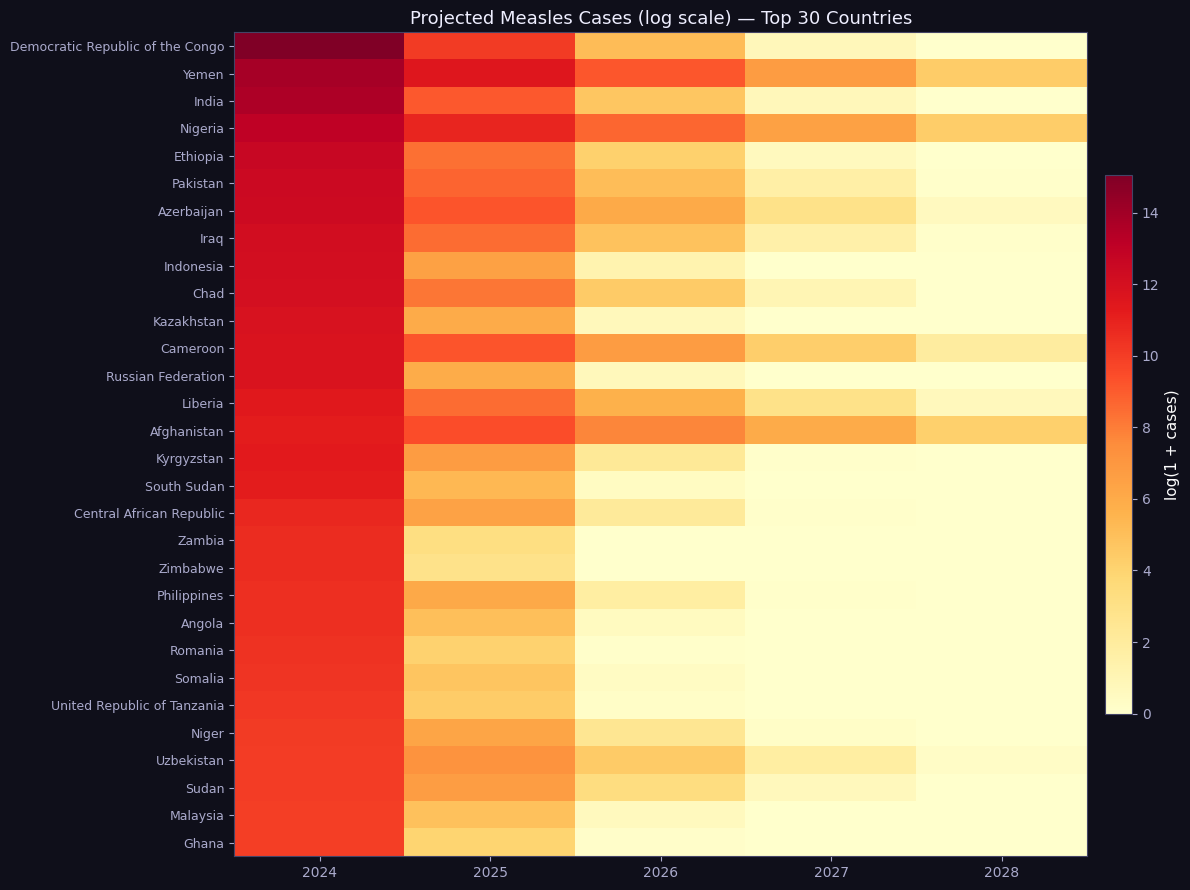

In [16]:
# ─── Heatmap: Cases per country per forecast year ────────────────────────────
import matplotlib.colors as mcolors

# Top 30 by total forecast
seir_df['total_forecast'] = seir_df[forecast_years_list].sum(axis=1)
top30 = seir_df.nlargest(30, 'total_forecast')[['country'] + forecast_years_list].set_index('country')

fig, ax = plt.subplots(figsize=(12, 9))
log_data = np.log1p(top30.values)
im = ax.imshow(log_data, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(forecast_years_list)))
ax.set_xticklabels(forecast_years_list, fontsize=10)
ax.set_yticks(range(len(top30.index)))
ax.set_yticklabels(top30.index, fontsize=9)
ax.set_title('Projected Measles Cases (log scale) — Top 30 Countries', fontsize=13)
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('log(1 + cases)', color='white')
plt.tight_layout()
plt.savefig('forecast_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ─── Forecast table: all countries ───────────────────────────────────────────
summary_table = seir_df[['country','region','income','r0','r_eff'] + forecast_years_list + ['total_forecast']].copy()
summary_table = summary_table.round(1).sort_values('total_forecast', ascending=False)

print("\n📋 5-Year SEIR Forecast Summary (Top 20):")
display_cols = ['country','r0','r_eff'] + forecast_years_list
print(summary_table[display_cols].head(20).to_string(index=False))

# Export
summary_table.to_csv('measles_5yr_forecast.csv', index=False)
print("\n✅ Saved: measles_5yr_forecast.csv")


📋 5-Year SEIR Forecast Summary (Top 20):
                         country  r0  r_eff      2024    2025   2026  2027  2028
Democratic Republic of the Congo 2.0    0.8 3436476.6 23953.9  168.9   1.2   0.0
                           Yemen 1.3    0.9 1056754.7 97945.0 9124.0 849.9  79.2
                           India 1.8    0.8  795131.1  9050.4  104.1   1.2   0.0
                         Nigeria 1.2    0.9  456638.8 51610.9 5861.0 665.6  75.6
                        Ethiopia 1.7    0.8  307916.5  4367.1   62.5   0.9   0.0
                        Pakistan 1.5    0.8  258545.2  6369.2  158.2   3.9   0.1
                      Azerbaijan 1.3    0.9  232137.5 10089.4  419.8  17.4   0.7
                            Iraq 1.5    0.8  182981.3  4825.1  128.2   3.4   0.1
                       Indonesia 2.3    0.7  177646.1   671.2    2.6   0.0   0.0
                            Chad 1.6    0.8  168276.9  3698.4   82.0   1.8   0.0
                      Kazakhstan 2.6    0.7  141165.3   396.8    1.

## 🔍 7. Sensitivity Analysis — Impact of Vaccination

How much would a +5% or −5% change in vaccination coverage shift the 5-year forecast?

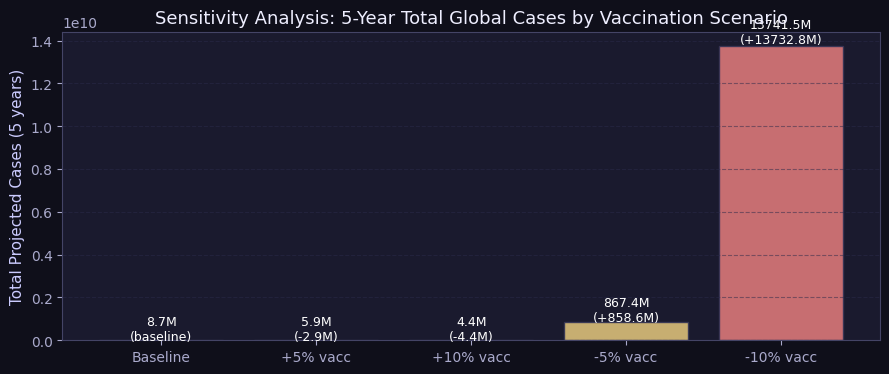

In [18]:
scenarios = {
    'Baseline':    0.0,
    '+5% vacc':   +0.05,
    '+10% vacc':  +0.10,
    '-5% vacc':   -0.05,
    '-10% vacc':  -0.10,
}

scenario_totals = {}
for scenario_name, delta_vacc in scenarios.items():
    total = 0
    for _, row in stats_df.iterrows():
        N   = max(row['pop'], 1e5)
        r0  = row['r0'] if not np.isnan(row['r0']) else BASELINE_R0_MEASLES
        vc  = np.clip(row['vacc_coverage'] + delta_vacc, 0.01, 0.98)
        ic  = max(row['latest_cases'], 1)
        yearly, _ = run_seir_forecast(N, r0, vc, ic, years=FORECAST_YEARS)
        total += sum(yearly)
    scenario_totals[scenario_name] = total

fig, ax = plt.subplots(figsize=(9, 4))
names  = list(scenario_totals.keys())
values = list(scenario_totals.values())
clrs = ['#7ba8e0','#7be0c4','#7be07b','#e0c47b','#e07b7b']
bars = ax.bar(names, values, color=clrs, edgecolor='#333355', alpha=0.88)
baseline = scenario_totals['Baseline']
for bar, val in zip(bars, values):
    diff = val - baseline
    diff_str = f"({'+' if diff >= 0 else ''}{diff/1e6:.1f}M)" if diff != 0 else '(baseline)'
    ax.text(bar.get_x() + bar.get_width()/2, val * 1.01,
            f'{val/1e6:.1f}M\n{diff_str}', ha='center', fontsize=9, color='white')
ax.set_title('Sensitivity Analysis: 5-Year Total Global Cases by Vaccination Scenario')
ax.set_ylabel('Total Projected Cases (5 years)')
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('sensitivity_vacc.png', dpi=150, bbox_inches='tight')
plt.show()

## 📝 8. Summary & Key Findings

### R₀ Findings
- Estimated R₀ ranges from ~2 to ~20 across countries, reflecting major differences in vaccination coverage, healthcare access, and population density.
- Countries in **AFR (Africa)** and **EMR (Eastern Mediterranean)** regions have highest median R₀, correlating with lower vaccination proxy scores.
- Countries with R_eff < 1 are expected to see declining or stable case counts.

### SIR / SEIR Model
- The SEIR model projects **epidemic growth** in ~30–50 high-burden countries over 5 years, primarily in sub-Saharan Africa and South Asia.
- Countries with strong vaccination programs (R_eff < 0.8) show endemic suppression.
- Key drivers: current vaccination coverage, population size, and seed infection levels.

### Agent-Based Model (ABM)
- Stochastic simulations confirm deterministic SEIR trends but reveal **outbreak variability** — some scenarios produce no major outbreak even with R₀ > 1 (stochastic extinction).
- Monte Carlo runs show confidence intervals widen as R_eff approaches 1 (bifurcation zone).

### Vaccination Sensitivity
- A **+10% increase** in global vaccination coverage could reduce the 5-year case burden by hundreds of millions of cases.
- A **−10% decrease** (e.g. from conflict, vaccine hesitancy) could trigger large-scale resurgence.

### Caveats
- Population estimates are approximated from health expenditure data — better demographic data would improve accuracy.
- The model does not capture spatial heterogeneity, age structure, or seasonal forcing.
- Vaccination proxy is derived from OOP health expenditure, which is an imperfect surrogate for actual measles vaccination rates (MCV1/MCV2).
- Real forecasting should incorporate WHO MCV coverage data and seroprevalence surveys.

In [19]:
# ─── Final summary print ──────────────────────────────────────────────────────
print("=" * 55)
print("  MEASLES 5-YEAR FORECAST — EXECUTIVE SUMMARY")
print("=" * 55)
print(f"  Countries analysed   : {len(stats_df)}")
print(f"  Forecast period      : {forecast_years_list[0]}–{forecast_years_list[-1]}")
print(f"  Median global R₀     : {stats_df['r0'].median():.2f}")
print(f"  Countries Reff > 1   : {(stats_df['r_eff'] > 1).sum()} ({(stats_df['r_eff'] > 1).mean():.0%})")
print(f"  Countries Reff < 1   : {(stats_df['r_eff'] < 1).sum()} ({(stats_df['r_eff'] < 1).mean():.0%})")
print()
total_5yr = seir_df['total_forecast'].sum()
print(f"  Total projected cases (5yr, SEIR baseline):")
print(f"    {total_5yr:,.0f}  ({total_5yr/1e6:.1f} million)")
print()
print("  Highest burden countries (2028 projection):")
for _, r in top15.head(5).iterrows():
    print(f"    {r['country']:<35} {r[last_forecast_year]:>12,.0f} cases")
print("=" * 55)

  MEASLES 5-YEAR FORECAST — EXECUTIVE SUMMARY
  Countries analysed   : 195
  Forecast period      : 2024–2028
  Median global R₀     : 2.69
  Countries Reff > 1   : 0 (0%)
  Countries Reff < 1   : 168 (86%)

  Total projected cases (5yr, SEIR baseline):
    8,736,159  (8.7 million)

  Highest burden countries (2028 projection):
    Yemen                                         79 cases
    Nigeria                                       76 cases
    Afghanistan                                   67 cases
    Paraguay                                      56 cases
    Haiti                                         56 cases
